In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

In [2]:
df = pd.read_csv('fraud_oracle.csv')
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [3]:
df.shape

(15420, 33)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  FraudFound_P          15420 non-null

In [5]:
df.columns.tolist()

['Month',
 'WeekOfMonth',
 'DayOfWeek',
 'Make',
 'AccidentArea',
 'DayOfWeekClaimed',
 'MonthClaimed',
 'WeekOfMonthClaimed',
 'Sex',
 'MaritalStatus',
 'Age',
 'Fault',
 'PolicyType',
 'VehicleCategory',
 'VehiclePrice',
 'FraudFound_P',
 'PolicyNumber',
 'RepNumber',
 'Deductible',
 'DriverRating',
 'Days_Policy_Accident',
 'Days_Policy_Claim',
 'PastNumberOfClaims',
 'AgeOfVehicle',
 'AgeOfPolicyHolder',
 'PoliceReportFiled',
 'WitnessPresent',
 'AgentType',
 'NumberOfSuppliments',
 'AddressChange_Claim',
 'NumberOfCars',
 'Year',
 'BasePolicy']

In [6]:
df.nunique().sort_values()

,0
AccidentArea,2
FraudFound_P,2
Fault,2
Sex,2
AgentType,2
PoliceReportFiled,2
WitnessPresent,2
VehicleCategory,3
Year,3
BasePolicy,3


In [7]:
df.describe()

,WeekOfMonth,WeekOfMonthClaimed,Age,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Year
count,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,2.788586,2.693969,39.855707,0.059857,7710.500000,8.483268,407.704280,2.487808,1994.866472
std,1.287585,1.259115,13.492377,0.237230,4451.514911,4.599948,43.950998,1.119453,0.803313
min,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,300.000000,1.000000,1994.000000
25%,2.000000,2.000000,31.000000,0.000000,3855.750000,5.000000,400.000000,1.000000,1994.000000
50%,3.000000,3.000000,38.000000,0.000000,7710.500000,8.000000,400.000000,2.000000,1995.000000
75%,4.000000,4.000000,48.000000,0.000000,11565.250000,12.000000,400.000000,3.000000,1996.000000
max,5.000000,5.000000,80.000000,1.000000,15420.000000,16.000000,700.000000,4.000000,1996.000000


In [8]:
target_counts = df['FraudFound_P'].value_counts()
target_share = target_counts / len(df) * 100
target_table = pd.DataFrame({'количество': target_counts, 'доля': target_share})
target_table

,количество,доля
FraudFound_P,,
0,14497,94.014267
1,923,5.985733


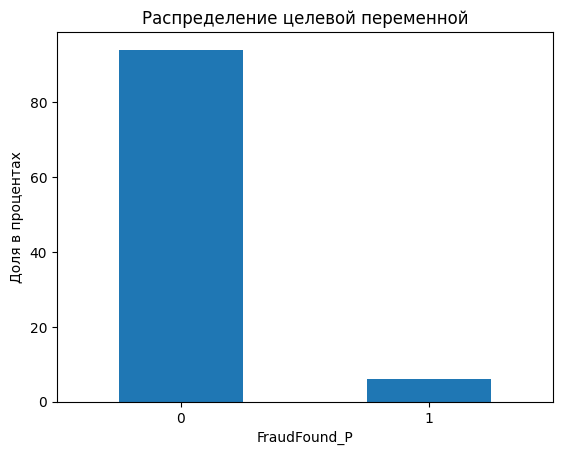

In [9]:
target_table['доля'].plot(kind='bar')
plt.title('Распределение целевой переменной')
plt.xlabel('FraudFound_P')
plt.ylabel('Доля в процентах')
plt.xticks(rotation=0)
plt.show()

In [10]:
df.isna().sum()

,0
Month,0
WeekOfMonth,0
DayOfWeek,0
Make,0
AccidentArea,0
DayOfWeekClaimed,0
MonthClaimed,0
WeekOfMonthClaimed,0
Sex,0
MaritalStatus,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df['PolicyNumber'].duplicated().sum()

np.int64(0)

In [13]:
df.drop(columns=['PolicyNumber'])

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15415,Nov,4,Friday,Toyota,Urban,Tuesday,Nov,5,Male,Married,...,6 years,31 to 35,No,No,External,none,no change,1 vehicle,1996,Collision
15416,Nov,5,Thursday,Pontiac,Urban,Friday,Dec,1,Male,Married,...,6 years,31 to 35,No,No,External,more than 5,no change,3 to 4,1996,Liability
15417,Nov,5,Thursday,Toyota,Rural,Friday,Dec,1,Male,Single,...,5 years,26 to 30,No,No,External,1 to 2,no change,1 vehicle,1996,Collision
15418,Dec,1,Monday,Toyota,Urban,Thursday,Dec,2,Female,Married,...,2 years,31 to 35,No,No,External,more than 5,no change,1 vehicle,1996,All Perils


In [14]:
object_cols = df.select_dtypes(include='object').columns.tolist()
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(object_cols)
print(numeric_cols)

['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'BasePolicy']
['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'FraudFound_P', 'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Year']


In [15]:
bad_values = {}
for col in object_cols:
  values = df[col].value_counts()
  if '0' in values.index:
    bad_values[col] = values.loc['0']
bad_values

{'DayOfWeekClaimed': np.int64(1), 'MonthClaimed': np.int64(1)}

In [16]:
df[['Age']].describe()

,Age
count,15420.000000
mean,39.855707
std,13.492377
min,0.000000
25%,31.000000
50%,38.000000
75%,48.000000
max,80.000000


In [17]:
(df['Age'] == 0).sum()

np.int64(320)

In [18]:
age_zero_mask = df['Age'] == 0
age_not_zero_mask = df['Age'] != 0
age_zero_table = pd.DataFrame({'группа': ['Age = 0', 'Age > 0', 'все данные'], 'количество': [age_zero_mask.sum(), age_not_zero_mask.sum(), len(df)], 'мошеннических случаев': [df.loc[age_zero_mask, 'FraudFound_P'].sum(), df.loc[age_not_zero_mask, 'FraudFound_P'].sum(), df['FraudFound_P'].sum()], 'процент мошеннических': [df.loc[age_zero_mask, 'FraudFound_P'].mean() * 100, df.loc[age_not_zero_mask, 'FraudFound_P'].mean() * 100, df['FraudFound_P'].mean() * 100]})
age_zero_table['процент мошеннических'] = age_zero_table['процент мошеннических'].round(2)
age_zero_table

,группа,количество,мошеннических случаев,процент мошеннических
0,Age = 0,320,31,9.69
1,Age > 0,15100,892,5.91
2,все данные,15420,923,5.99


In [19]:
df_clean = df.copy()
df_clean['Age'] = df_clean['Age'].replace(0, np.nan)
df_clean['DayOfWeekClaimed'] = df_clean['DayOfWeekClaimed'].replace('0', np.nan)
df_clean['MonthClaimed'] = df_clean['MonthClaimed'].replace('0', np.nan)

df_clean.isna().sum().sort_values(ascending=False).head(10)

,0
Age,320
DayOfWeekClaimed,1
MonthClaimed,1
Month,0
WeekOfMonth,0
AccidentArea,0
Make,0
WeekOfMonthClaimed,0
DayOfWeek,0
Sex,0


In [20]:
df_clean['Age'].describe()

,Age
count,15100.000000
mean,40.700331
std,12.309493
min,16.000000
25%,31.000000
50%,39.000000
75%,49.000000
max,80.000000


In [21]:
features_table = pd.DataFrame({
  'Признак': [
    'Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea',
    'DayOfWeekClaimed', 'MonthClaimed', 'Sex', 'MaritalStatus',
    'Age', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice',
    'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating',
    'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims',
    'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled',
    'WitnessPresent', 'AgentType', 'NumberOfSuppliments',
    'AddressChange_Claim', 'NumberOfCars', 'Year', 'BasePolicy',
    'FraudFound_P'
  ],
  'Смысл': [
    'месяц ДТП', 'неделя месяца ДТП', 'день недели ДТП', 'марка авто',
    'район ДТП', 'день недели обращения', 'месяц обращения',
    'пол водителя', 'семейное положение', 'возраст водителя',
    'кто виноват', 'тип полиса', 'категория авто', 'цена авто',
    'номер полиса', 'номер представителя', 'франшиза',
    'рейтинг водителя', 'сколько дней полису до ДТП',
    'сколько дней от полиса до обращения', 'прошлые обращения',
    'возраст машины', 'возраст держателя полиса',
    'был ли полицейский отчет', 'были ли свидетели',
    'тип агента', 'количество дополнительных выплат',
    'смена адреса перед заявкой', 'количество машин',
    'год наблюдения', 'базовый тип полиса',
    'целевой признак мошенничества'
  ],
  'Тип для анализа': [
    'категориальный', 'порядковый', 'категориальный', 'категориальный',
    'категориальный', 'категориальный', 'категориальный',
    'категориальный', 'категориальный', 'числовой',
    'категориальный', 'категориальный', 'категориальный',
    'порядковый', 'технический', 'порядковый', 'числовой',
    'порядковый', 'порядковый', 'порядковый',
    'порядковый', 'порядковый', 'порядковый',
    'бинарный', 'бинарный', 'бинарный', 'порядковый',
    'порядковый', 'порядковый', 'временной',
    'категориальный', 'target'
  ]
})

features_table

,Признак,Смысл,Тип для анализа
0,Month,месяц ДТП,категориальный
1,WeekOfMonth,неделя месяца ДТП,порядковый
2,DayOfWeek,день недели ДТП,категориальный
3,Make,марка авто,категориальный
4,AccidentArea,район ДТП,категориальный
5,DayOfWeekClaimed,день недели обращения,категориальный
6,MonthClaimed,месяц обращения,категориальный
7,Sex,пол водителя,категориальный
8,MaritalStatus,семейное положение,категориальный
9,Age,возраст водителя,числовой


In [22]:
numeric_cols_clean = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols_clean

['WeekOfMonth',
 'WeekOfMonthClaimed',
 'Age',
 'FraudFound_P',
 'PolicyNumber',
 'RepNumber',
 'Deductible',
 'DriverRating',
 'Year']

In [23]:
df_clean[numeric_cols_clean].describe()

,WeekOfMonth,WeekOfMonthClaimed,Age,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Year
count,15420.000000,15420.000000,15100.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,2.788586,2.693969,40.700331,0.059857,7710.500000,8.483268,407.704280,2.487808,1994.866472
std,1.287585,1.259115,12.309493,0.237230,4451.514911,4.599948,43.950998,1.119453,0.803313
min,1.000000,1.000000,16.000000,0.000000,1.000000,1.000000,300.000000,1.000000,1994.000000
25%,2.000000,2.000000,31.000000,0.000000,3855.750000,5.000000,400.000000,1.000000,1994.000000
50%,3.000000,3.000000,39.000000,0.000000,7710.500000,8.000000,400.000000,2.000000,1995.000000
75%,4.000000,4.000000,49.000000,0.000000,11565.250000,12.000000,400.000000,3.000000,1996.000000
max,5.000000,5.000000,80.000000,1.000000,15420.000000,16.000000,700.000000,4.000000,1996.000000


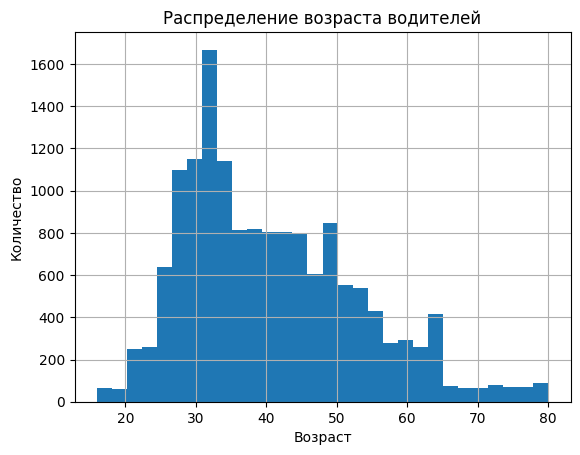

In [24]:
df_clean['Age'].hist(bins=30)
plt.title('Распределение возраста водителей')
plt.xlabel('Возраст')
plt.ylabel('Количество')
plt.show()

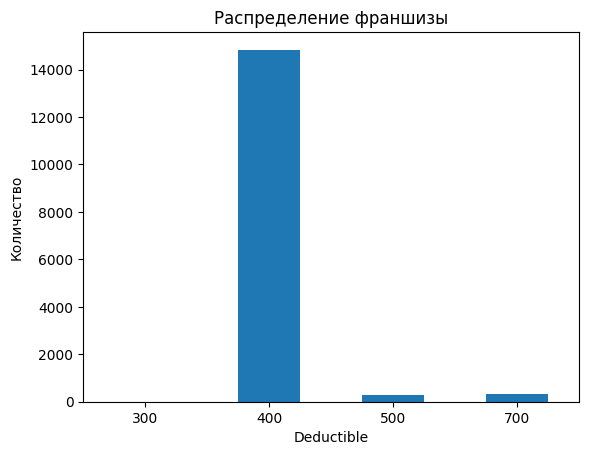

In [25]:
df_clean['Deductible'].value_counts().sort_index().plot(kind='bar')
plt.title('Распределение франшизы')
plt.xlabel('Deductible')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.show()

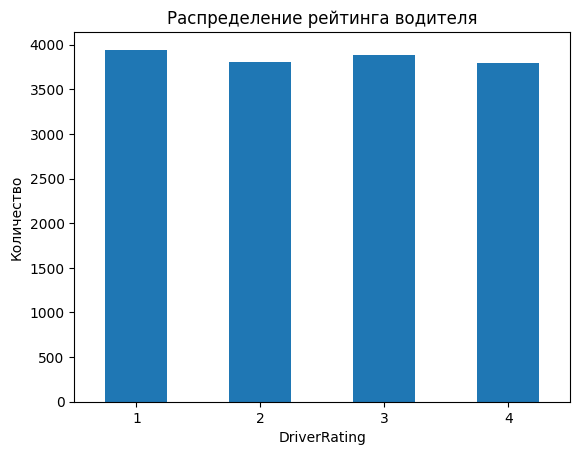

In [26]:
df_clean['DriverRating'].value_counts().sort_index().plot(kind='bar')
plt.title('Распределение рейтинга водителя')
plt.xlabel('DriverRating')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.show()

In [27]:
df_clean['AccidentArea'].value_counts()

,count
AccidentArea,
Urban,13822
Rural,1598


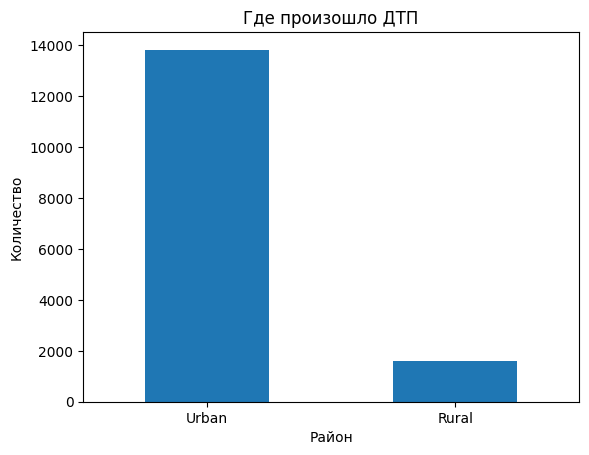

In [28]:
df_clean['AccidentArea'].value_counts().plot(kind='bar')
plt.title('Где произошло ДТП')
plt.xlabel('Район')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.show()

In [29]:
df_clean['Fault'].value_counts()

,count
Fault,
Policy Holder,11230
Third Party,4190


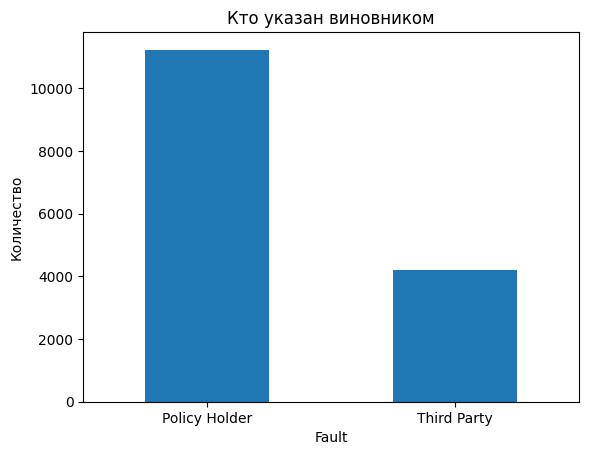

In [30]:
df_clean['Fault'].value_counts().plot(kind='bar')
plt.title('Кто указан виновником')
plt.xlabel('Fault')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.show()

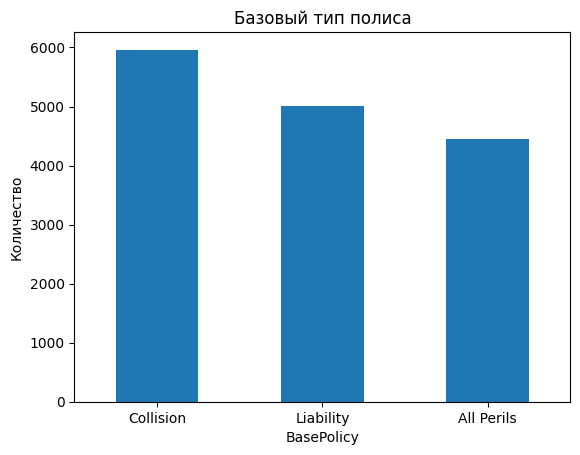

In [31]:
df_clean['BasePolicy'].value_counts().plot(kind='bar')
plt.title('Базовый тип полиса')
plt.xlabel('BasePolicy')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.show()

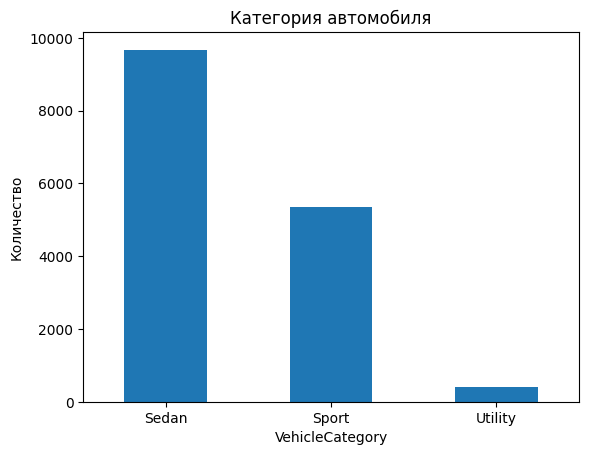

In [32]:
df_clean['VehicleCategory'].value_counts().plot(kind='bar')
plt.title('Категория автомобиля')
plt.xlabel('VehicleCategory')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.show()

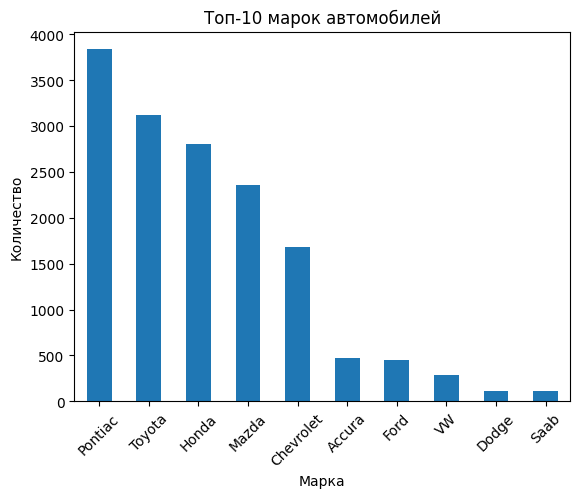

In [33]:
top_make = df_clean['Make'].value_counts().head(10)
top_make.plot(kind='bar')
plt.title('Топ-10 марок автомобилей')
plt.xlabel('Марка')
plt.ylabel('Количество')
plt.xticks(rotation=45)
plt.show()

In [34]:
def fraud_table(data, col):
  result = data.groupby(col)['FraudFound_P'].agg(['count', 'sum', 'mean'])
  result = result.rename(columns={'count': 'количество', 'sum': 'fraud_count', 'mean': 'fraud_rate'})
  result['fraud_rate_percent'] = result['fraud_rate'] * 100
  return result.sort_values('fraud_rate_percent', ascending=False)

In [35]:
fraud_table(df_clean, 'AccidentArea')

,количество,fraud_count,fraud_rate,fraud_rate_percent
AccidentArea,,,,
Rural,1598,133,0.083229,8.322904
Urban,13822,790,0.057155,5.715526


In [36]:
fraud_table(df_clean, 'Fault')

,количество,fraud_count,fraud_rate,fraud_rate_percent
Fault,,,,
Policy Holder,11230,886,0.078896,7.889581
Third Party,4190,37,0.008831,0.883055


In [37]:
fraud_table(df_clean, 'BasePolicy')

,количество,fraud_count,fraud_rate,fraud_rate_percent
BasePolicy,,,,
All Perils,4449,452,0.101596,10.159586
Collision,5962,435,0.072962,7.296209
Liability,5009,36,0.007187,0.718706


In [38]:
fraud_table(df_clean, 'PolicyType')

,количество,fraud_count,fraud_rate,fraud_rate_percent
PolicyType,,,,
Sport - Collision,348,48,0.137931,13.793103
Utility - All Perils,340,41,0.120588,12.058824
Sedan - All Perils,4087,411,0.100563,10.056276
Utility - Collision,30,3,0.100000,10.000000
Sedan - Collision,5584,384,0.068768,6.876791
Sedan - Liability,4987,36,0.007219,0.721877
Sport - All Perils,22,0,0.000000,0.000000
Sport - Liability,1,0,0.000000,0.000000
Utility - Liability,21,0,0.000000,0.000000


In [39]:
fraud_table(df_clean, 'VehicleCategory')

,количество,fraud_count,fraud_rate,fraud_rate_percent
VehicleCategory,,,,
Utility,391,44,0.112532,11.253197
Sedan,9671,795,0.082205,8.220453
Sport,5358,84,0.015677,1.567749


In [40]:
fraud_table(df_clean, 'VehiclePrice')

,количество,fraud_count,fraud_rate,fraud_rate_percent
VehiclePrice,,,,
less than 20000,1096,103,0.093978,9.397810
more than 69000,2164,189,0.087338,8.733826
40000 to 59000,461,31,0.067245,6.724512
20000 to 29000,8079,421,0.052110,5.211041
30000 to 39000,3533,175,0.049533,4.953297
60000 to 69000,87,4,0.045977,4.597701


In [41]:
fraud_table(df_clean, 'PastNumberOfClaims')

,количество,fraud_count,fraud_rate,fraud_rate_percent
PastNumberOfClaims,,,,
none,4352,339,0.077895,7.789522
1,3573,222,0.062133,6.213266
2 to 4,5485,294,0.053601,5.360073
more than 4,2010,68,0.033831,3.383085


In [42]:
fraud_table(df_clean, 'AddressChange_Claim')

,количество,fraud_count,fraud_rate,fraud_rate_percent
AddressChange_Claim,,,,
under 6 months,4,3,0.750000,75.000000
2 to 3 years,291,51,0.175258,17.525773
1 year,170,11,0.064706,6.470588
no change,14324,825,0.057596,5.759564
4 to 8 years,631,33,0.052298,5.229794


In [43]:
fraud_table(df_clean, 'PoliceReportFiled')

,количество,fraud_count,fraud_rate,fraud_rate_percent
PoliceReportFiled,,,,
No,14992,907,0.060499,6.049893
Yes,428,16,0.037383,3.738318


In [44]:
fraud_table(df_clean, 'WitnessPresent')

,количество,fraud_count,fraud_rate,fraud_rate_percent
WitnessPresent,,,,
No,15333,920,0.060001,6.000130
Yes,87,3,0.034483,3.448276


In [45]:
fraud_table(df_clean, 'AgentType')

,количество,fraud_count,fraud_rate,fraud_rate_percent
AgentType,,,,
External,15179,919,0.060544,6.054417
Internal,241,4,0.016598,1.659751


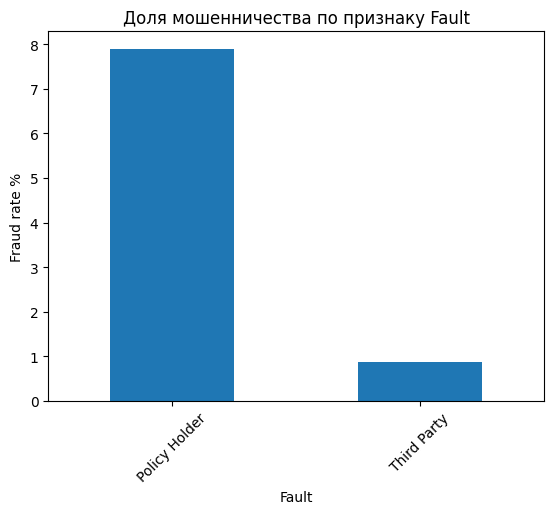

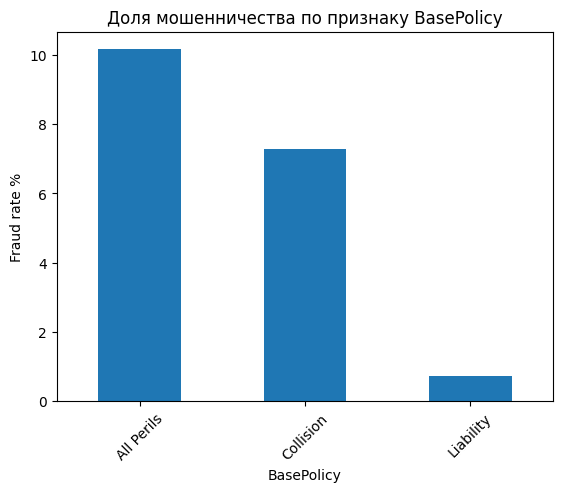

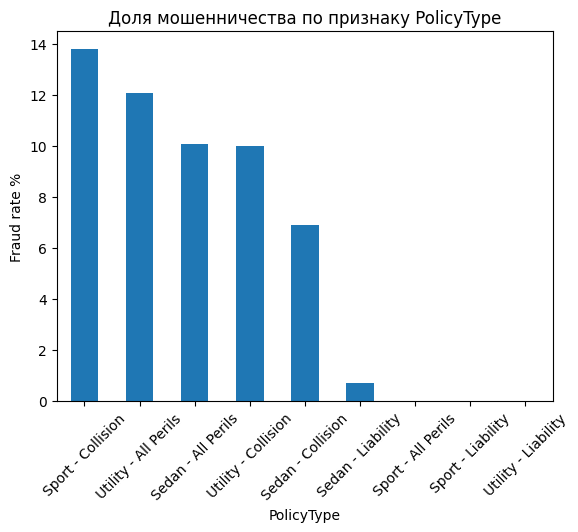

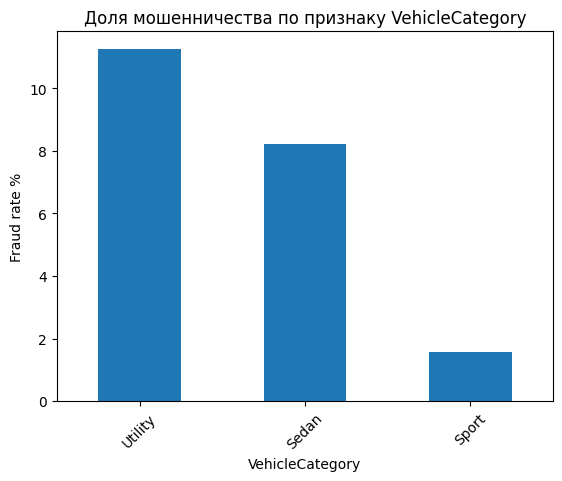

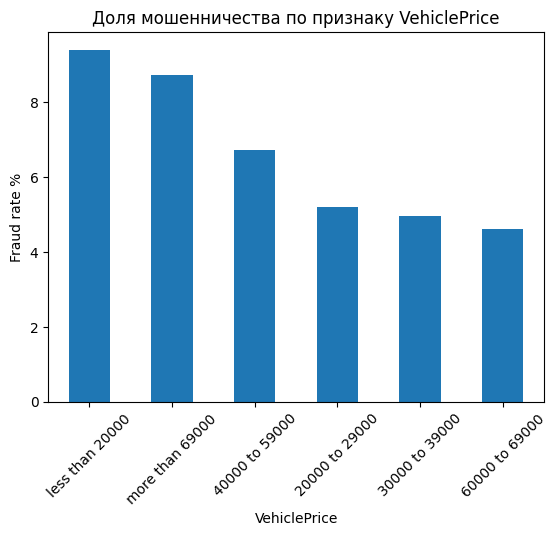

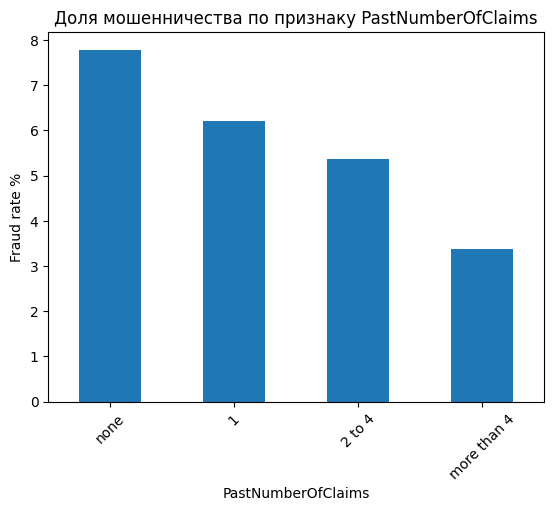

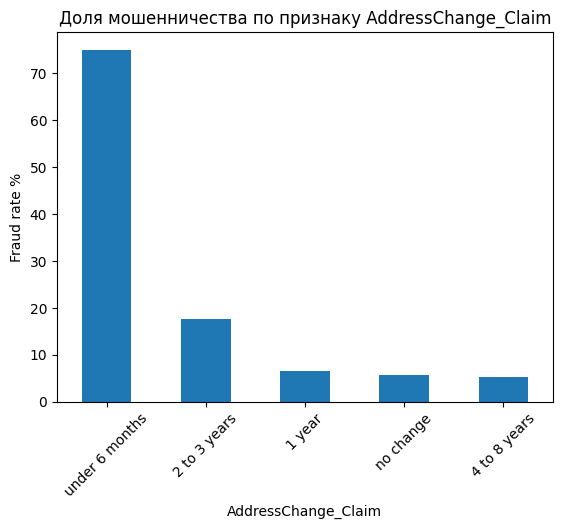

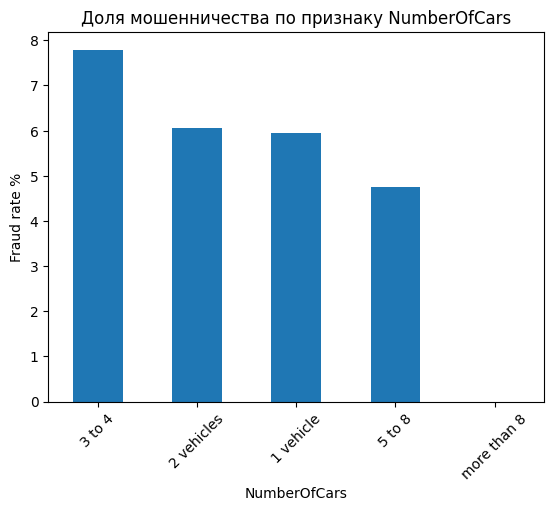

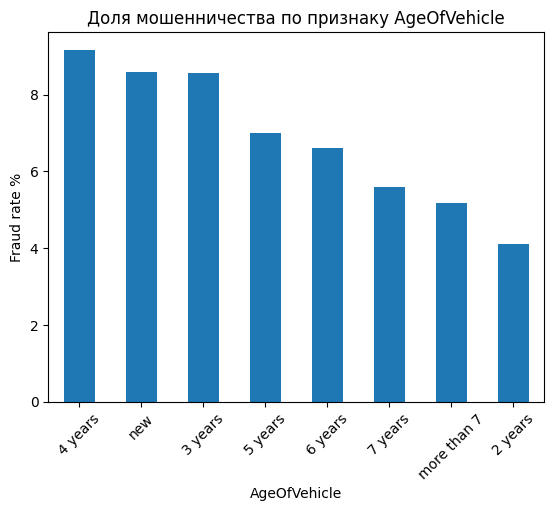

In [46]:
important_cols = ['Fault', 'BasePolicy', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'PastNumberOfClaims', 'AddressChange_Claim', 'NumberOfCars', 'AgeOfVehicle']
for col in important_cols:
  plot_data = fraud_table(df_clean, col)
  plot_data['fraud_rate_percent'].plot(kind='bar')
  plt.title('Доля мошенничества по признаку ' + col)
  plt.xlabel(col)
  plt.ylabel('Fraud rate %')
  plt.xticks(rotation=45)
  plt.show()

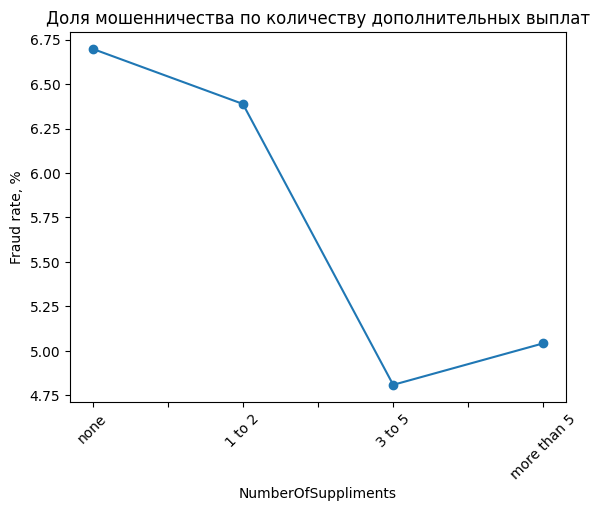

In [47]:
supp_order = ['none', '1 to 2', '3 to 5', 'more than 5']
supp_fraud = (df_clean.groupby('NumberOfSuppliments')['FraudFound_P'].mean().reindex(supp_order) * 100)
supp_fraud.plot(marker='o')
plt.title('Доля мошенничества по количеству дополнительных выплат')
plt.xlabel('NumberOfSuppliments')
plt.ylabel('Fraud rate, %')
plt.xticks(rotation=45)
plt.show()

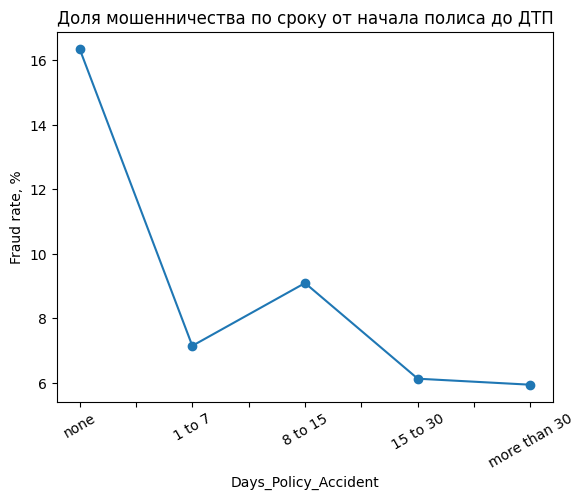

In [48]:
days_order = ['none', '1 to 7', '8 to 15', '15 to 30', 'more than 30']
days_accident_fraud = ( df_clean.groupby('Days_Policy_Accident')['FraudFound_P'].mean().reindex(days_order) * 100)
days_accident_fraud.plot(marker='o')
plt.title('Доля мошенничества по сроку от начала полиса до ДТП')
plt.xlabel('Days_Policy_Accident')
plt.ylabel('Fraud rate, %')
plt.xticks(rotation=30)
plt.show()

In [49]:
df_clean['AgeGroup'] = pd.cut(df_clean['Age'], bins=[0, 20, 30, 40, 50, 60, 100], labels=['до 20', '21-30', '31-40', '41-50', '51-60', '60+'])
age_fraud = df_clean.groupby('AgeGroup', observed=False)['FraudFound_P'].agg(['count', 'mean'])
age_fraud['fraud_rate_percent'] = age_fraud['mean'] * 100
age_fraud

,count,mean,fraud_rate_percent
AgeGroup,,,
до 20,123,0.146341,14.634146
21-30,3396,0.059776,5.977621
31-40,4828,0.065659,6.565866
41-50,3475,0.053525,5.352518
51-60,2096,0.048664,4.866412
60+,1182,0.055838,5.583756


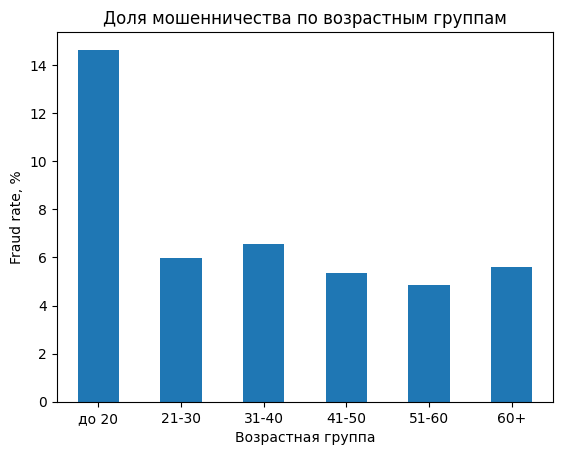

In [50]:
age_fraud['fraud_rate_percent'].plot(kind='bar')
plt.title('Доля мошенничества по возрастным группам')
plt.xlabel('Возрастная группа')
plt.ylabel('Fraud rate, %')
plt.xticks(rotation=0)
plt.show()

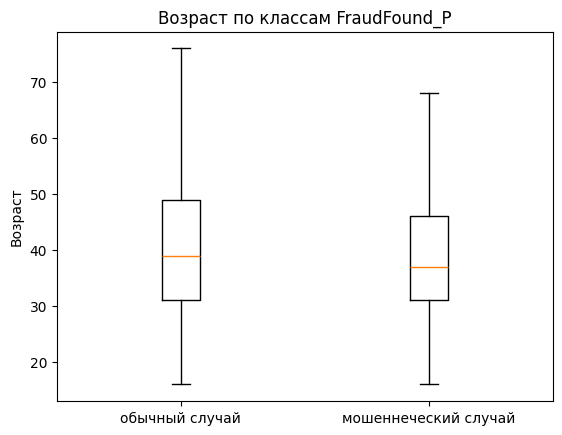

In [51]:
data = [df_clean.loc[df_clean['FraudFound_P'] == 0, 'Age'].dropna(),df_clean.loc[df_clean['FraudFound_P'] == 1, 'Age'].dropna()]
plt.boxplot(data, tick_labels=['обычный случай', 'мошеннеческий случай'], showfliers=False)
plt.title('Возраст по классам FraudFound_P')
plt.ylabel('Возраст')
plt.show()

In [52]:
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_fraud = df_clean.groupby('Month')['FraudFound_P'].mean().reindex(month_order) * 100
month_fraud

,FraudFound_P
Month,
Jan,6.165840
Feb,6.477093
Mar,7.500000
Apr,6.250000
May,6.876372
Jun,6.056018
Jul,4.773270
Aug,7.453416
Sep,6.129032


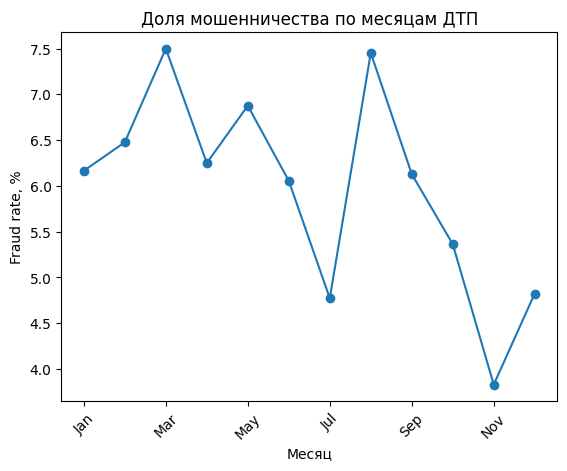

In [53]:
month_fraud.plot(marker='o')
plt.title('Доля мошенничества по месяцам ДТП')
plt.xlabel('Месяц')
plt.ylabel('Fraud rate, %')
plt.xticks(rotation=45)
plt.show()

In [54]:
claimed_month_fraud = df_clean.groupby('MonthClaimed')['FraudFound_P'].mean().reindex(month_order) * 100
claimed_month_fraud

,FraudFound_P
MonthClaimed,
Jan,6.362379
Feb,6.060606
Mar,7.195846
Apr,6.451613
May,7.228916
Jun,6.032483
Jul,4.571429
Aug,8.170515
Sep,6.280193


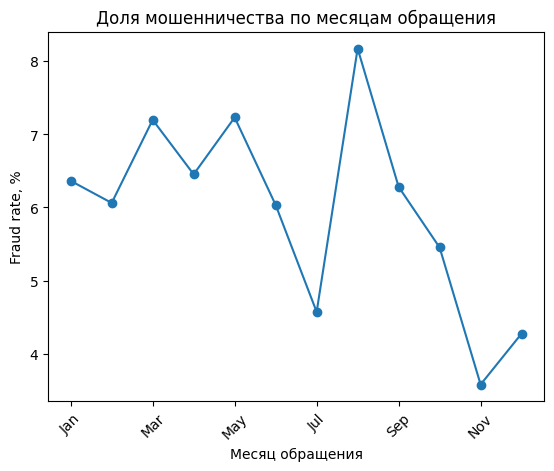

In [55]:
claimed_month_fraud.plot(marker='o')
plt.title('Доля мошенничества по месяцам обращения')
plt.xlabel('Месяц обращения')
plt.ylabel('Fraud rate, %')
plt.xticks(rotation=45)
plt.show()

In [56]:
year_table = df_clean.groupby('Year')['FraudFound_P'].agg(['count', 'mean'])
year_table['fraud_rate_percent'] = year_table['mean'] * 100
year_table

,count,mean,fraud_rate_percent
Year,,,
1994,6142,0.066591,6.659069
1995,5195,0.057940,5.794033
1996,4083,0.052168,5.216752


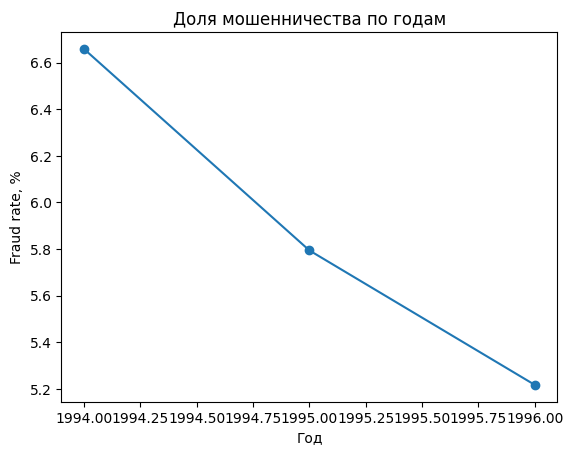

In [57]:
year_table['fraud_rate_percent'].plot(marker='o')
plt.title('Доля мошенничества по годам')
plt.xlabel('Год')
plt.ylabel('Fraud rate, %')
plt.show()

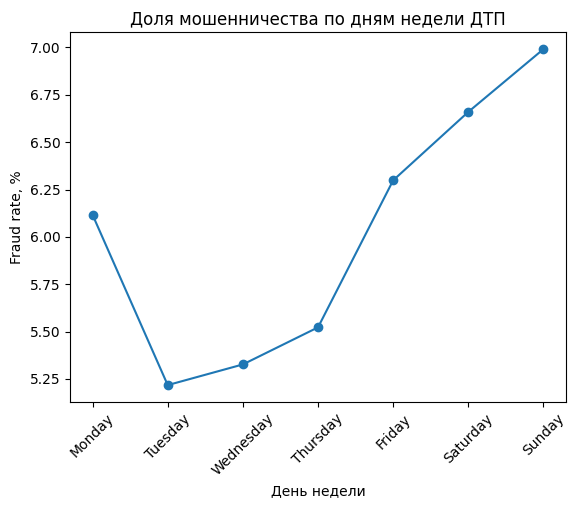

In [58]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_fraud = (df_clean.groupby('DayOfWeek')['FraudFound_P'].mean().reindex(day_order) * 100)
day_fraud.plot(marker='o')
plt.title('Доля мошенничества по дням недели ДТП')
plt.xlabel('День недели')
plt.ylabel('Fraud rate, %')
plt.xticks(rotation=45)
plt.show()

In [59]:
fault_policy = pd.crosstab(df_clean['Fault'], df_clean['BasePolicy'], values=df_clean['FraudFound_P'], aggfunc='mean') * 100
fault_policy

BasePolicy,All Perils,Collision,Liability
Fault,,,
Policy Holder,15.588130,9.997591,0.817375
Third Party,0.968523,1.104362,0.137552


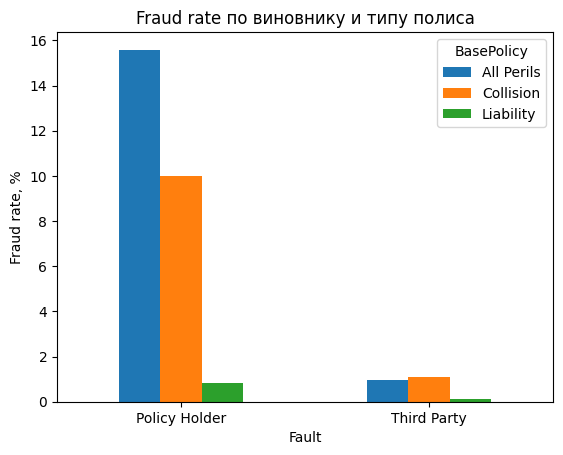

In [60]:
fault_policy.plot(kind='bar')
plt.title('Fraud rate по виновнику и типу полиса')
plt.xlabel('Fault')
plt.ylabel('Fraud rate, %')
plt.xticks(rotation=0)
plt.legend(title='BasePolicy')
plt.show()

In [61]:
category_policy = pd.crosstab(df_clean['VehicleCategory'], df_clean['BasePolicy'], values=df_clean['FraudFound_P'], aggfunc='mean') * 100
category_policy

BasePolicy,All Perils,Collision,Liability
VehicleCategory,,,
Sedan,10.056276,6.876791,NaN
Sport,0.000000,13.793103,0.721732
Utility,12.058824,10.000000,0.000000


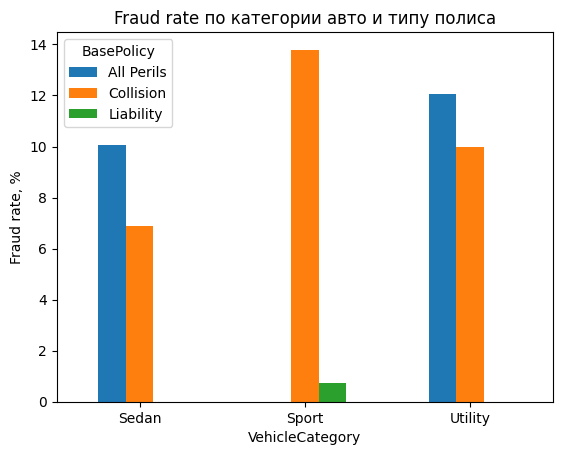

In [62]:
category_policy.plot(kind='bar')
plt.title('Fraud rate по категории авто и типу полиса')
plt.xlabel('VehicleCategory')
plt.ylabel('Fraud rate, %')
plt.xticks(rotation=0)
plt.legend(title='BasePolicy')
plt.show()

In [63]:
address_fault = pd.crosstab(df_clean['AddressChange_Claim'], df_clean['Fault'], values=df_clean['FraudFound_P'], aggfunc='mean') * 100
address_fault

Fault,Policy Holder,Third Party
AddressChange_Claim,,
1 year,8.943089,0.000000
2 to 3 years,7.009346,46.753247
4 to 8 years,7.036247,0.000000
no change,7.907869,0.025615
under 6 months,75.000000,NaN


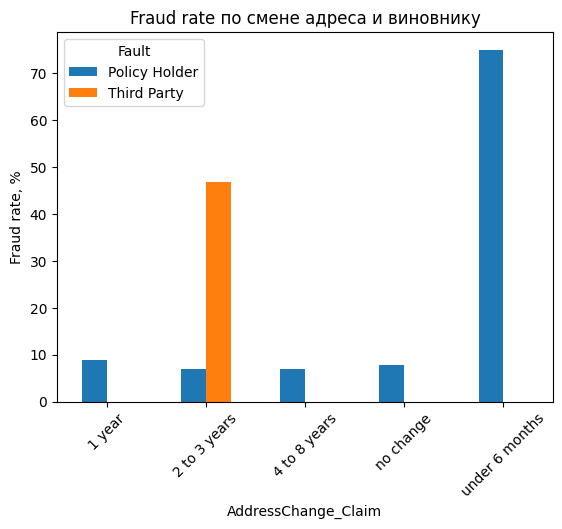

In [64]:
address_fault.plot(kind='bar')
plt.title('Fraud rate по смене адреса и виновнику')
plt.xlabel('AddressChange_Claim')
plt.ylabel('Fraud rate, %')
plt.xticks(rotation=45)
plt.legend(title='Fault')
plt.show()

In [65]:
witness_police = pd.crosstab(df_clean['WitnessPresent'], df_clean['PoliceReportFiled'], values=df_clean['FraudFound_P'], aggfunc='mean') * 100
witness_police

PoliceReportFiled,No,Yes
WitnessPresent,,
No,6.055537,3.865979
Yes,4.255319,2.500000


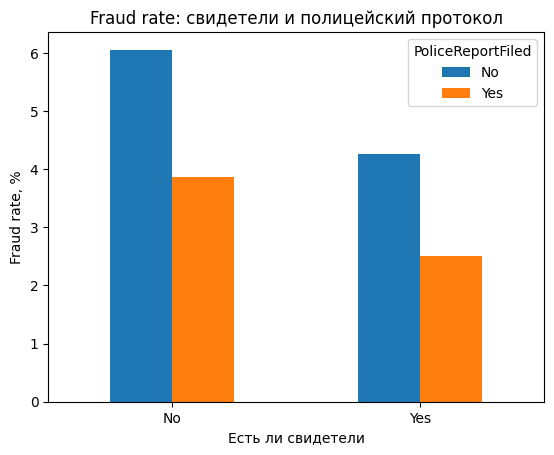

In [66]:
witness_police.plot(kind='bar')
plt.title('Fraud rate: свидетели и полицейский протокол')
plt.xlabel('Есть ли свидетели')
plt.ylabel('Fraud rate, %')
plt.xticks(rotation=0)
plt.legend(title='PoliceReportFiled')
plt.show()

In [67]:
def cramers_v(table):
  chi2 = stats.chi2_contingency(table)[0]
  n = table.sum().sum()
  r, k = table.shape
  return np.sqrt((chi2 / n) / min(k - 1, r - 1))

In [68]:
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
chi_results = []
for col in cat_cols:
  table = pd.crosstab(df_clean[col], df_clean['FraudFound_P'])
  chi2, p_value, dof, expected = stats.chi2_contingency(table)
  chi_results.append([col, p_value, cramers_v(table), df_clean[col].nunique()])
chi_results = pd.DataFrame(chi_results, columns=['Признак', 'p-value', 'Cramers_V', 'Количество категорий']).sort_values('Cramers_V', ascending=False)
chi_results

,Признак,p-value,Cramers_V,Количество категорий
9,PolicyType,1.848256e-89,0.168422,9
23,BasePolicy,3.325192e-88,0.161633,3
10,VehicleCategory,6.648398e-64,0.137360,3
8,Fault,1.428036e-59,0.131082,2
21,AddressChange_Claim,9.652105e-22,0.082414,5
11,VehiclePrice,2.983598e-13,0.066294,6
2,Make,2.195889e-06,0.062279,19
14,PastNumberOfClaims,1.433718e-11,0.058903,4
5,MonthClaimed,1.495245e-05,0.052316,12
16,AgeOfPolicyHolder,6.150520e-05,0.046263,9


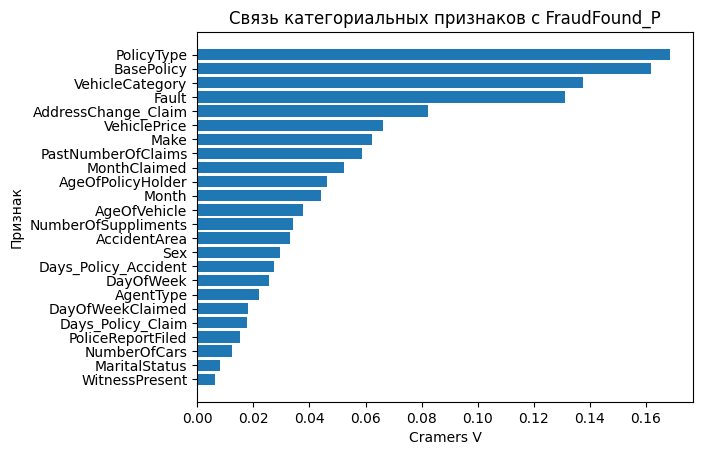

In [69]:
chi_plot = chi_results.sort_values('Cramers_V')
plt.barh(chi_plot['Признак'], chi_plot['Cramers_V'])
plt.title('Связь категориальных признаков с FraudFound_P')
plt.xlabel('Cramers V')
plt.ylabel('Признак')
plt.show()

In [70]:
corr_with_target = df_clean[numeric_cols_clean].corr(method='spearman')['FraudFound_P'].drop('FraudFound_P').sort_values(ascending=False)
corr_with_target

,FraudFound_P
Deductible,0.040905
DriverRating,0.007257
WeekOfMonthClaimed,-0.005262
RepNumber,-0.007532
WeekOfMonth,-0.011944
PolicyNumber,-0.020345
Age,-0.022145
Year,-0.024883


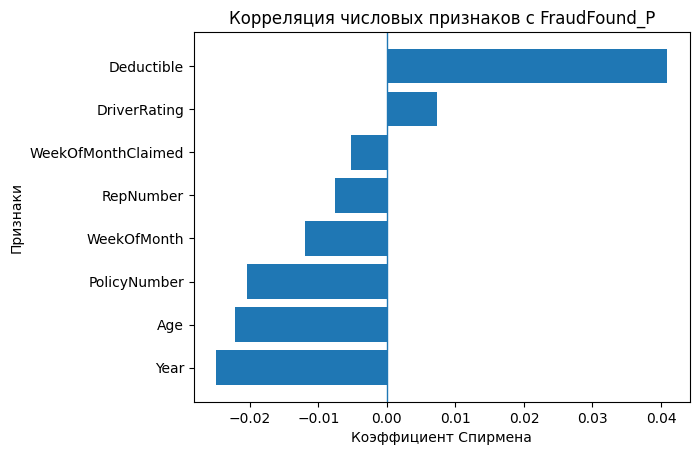

In [71]:
corr_plot = corr_with_target.sort_values()
plt.barh(corr_plot.index, corr_plot)
plt.axvline(0, linewidth=1)
plt.title('Корреляция числовых признаков с FraudFound_P')
plt.xlabel('Коэффициент Спирмена')
plt.ylabel('Признаки')
plt.show()

In [72]:
month_to_num = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6, 'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}
df_clean['Month_num'] = df_clean['Month'].map(month_to_num)
df_clean['MonthClaimed_num'] = df_clean['MonthClaimed'].map(month_to_num)
df_clean['ClaimMonthDelay'] = df_clean['MonthClaimed_num'] - df_clean['Month_num']
df_clean.loc[df_clean['ClaimMonthDelay'] < 0, 'ClaimMonthDelay'] = df_clean['ClaimMonthDelay'] + 12
df_clean['IsYoungDriver'] = (df_clean['Age'] < 25).astype(int)
df_clean['IsPolicyHolderFault'] = (df_clean['Fault'] == 'Policy Holder').astype(int)
df_clean['HasPoliceReport'] = (df_clean['PoliceReportFiled'] == 'Yes').astype(int)
df_clean['HasWitness'] = (df_clean['WitnessPresent'] == 'Yes').astype(int)
df_clean['AddressChanged'] = (df_clean['AddressChange_Claim'] != 'no change').astype(int)
df_clean['NewPolicyBeforeAccident'] = (df_clean['Days_Policy_Accident'] != 'more than 30').astype(int)
df_clean[['ClaimMonthDelay', 'IsYoungDriver', 'IsPolicyHolderFault', 'HasPoliceReport', 'HasWitness', 'AddressChanged', 'NewPolicyBeforeAccident', 'FraudFound_P']].head()

,ClaimMonthDelay,IsYoungDriver,IsPolicyHolderFault,HasPoliceReport,HasWitness,AddressChanged,NewPolicyBeforeAccident,FraudFound_P
0,1.0,1,1,0,0,1,0,0
1,0.0,0,1,1,0,0,0,0
2,1.0,0,1,0,0,0,0,0
3,1.0,0,0,1,0,0,0,0
4,1.0,0,0,0,0,0,0,0


In [73]:
new_features = ['ClaimMonthDelay', 'IsYoungDriver', 'IsPolicyHolderFault', 'HasPoliceReport', 'HasWitness', 'AddressChanged', 'NewPolicyBeforeAccident']
new_feature_table = df_clean.groupby('FraudFound_P')[new_features].mean()
new_feature_table

,ClaimMonthDelay,IsYoungDriver,IsPolicyHolderFault,HasPoliceReport,HasWitness,AddressChanged,NewPolicyBeforeAccident
FraudFound_P,,,,,,,
0,0.370309,0.040491,0.713527,0.028420,0.005794,0.068842,0.010692
1,0.448537,0.048754,0.959913,0.017335,0.003250,0.106176,0.019502


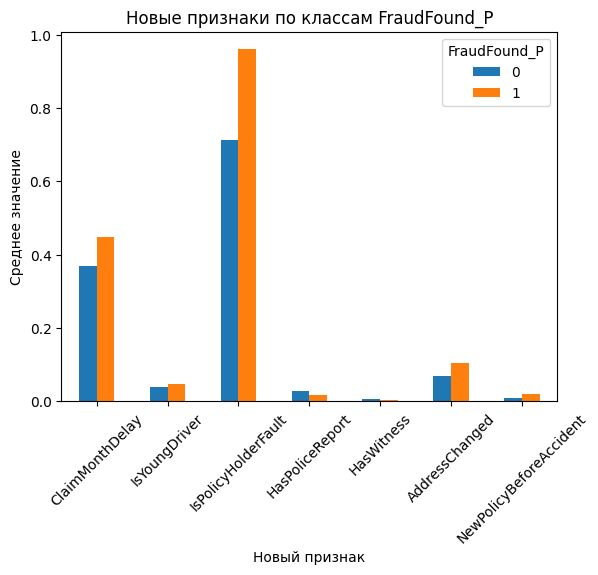

In [74]:
new_feature_table.T.plot(kind='bar')
plt.title('Новые признаки по классам FraudFound_P')
plt.xlabel('Новый признак')
plt.ylabel('Среднее значение')
plt.xticks(rotation=45)
plt.legend(title='FraudFound_P')
plt.show()

In [75]:
!pip install -q --upgrade wandb torchinfo scikit-learn joblib tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.7/58.7 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 6.7 MB/s eta 0:00:00


In [76]:
import os
import random
import json
import copy
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
  roc_auc_score,
  average_precision_score,
  precision_score,
  recall_score,
  f1_score,
  confusion_matrix,
  classification_report,
  roc_curve,
  precision_recall_curve
)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import wandb

In [77]:
def seed_everything(seed):
  random.seed(seed)
  os.environ['PYTHONHASHSEED'] = str(seed)
  np.random.seed(seed)

  torch.manual_seed(seed)
  torch.cuda.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)

  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False

In [78]:
class CFG:
  wandb = True
  seed = 42
  target = "FraudFound_P"
  test_size = 0.15
  val_size = 0.15
  num_epochs = 10
  train_batch_size = 128
  test_batch_size = 512
  num_workers = 0
  lr = 3e-4
  weight_decay = 1e-4
  threshold = 0.5
  patience = 8
  input_dim = None

In [79]:
def class2dict(f):
  return dict((name, getattr(f, name)) for name in dir(f) if not name.startswith('__'))

seed_everything(CFG.seed)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cpu')

In [80]:
if CFG.wandb:
  wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: annneee4kkaa (annneee4kkaa-hse) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [81]:
data_nn = df_clean.copy()

drop_cols = ['PolicyNumber', 'Month_num', 'MonthClaimed_num', 'AgeGroup']
data_nn = data_nn.drop(columns=[col for col in drop_cols if col in data_nn.columns])

for col in ['RepNumber', 'Year']:
  if col in data_nn.columns:
    data_nn[col] = data_nn[col].astype('object')

X = data_nn.drop(columns=[CFG.target])
y = data_nn[CFG.target].astype(int)

print('Размер X:', X.shape)
print('Размер y:', y.shape)
print('Доля мошеннических случаев:', round(y.mean(), 4))

Размер X: (15420, 38)
Размер y: (15420,)
Доля мошеннических случаев: 0.0599


In [82]:
X_train_val_raw, X_test_raw, y_train_val, y_test = train_test_split(X, y, test_size=CFG.test_size, random_state=CFG.seed, stratify=y)

relative_val_size = CFG.val_size / (1 - CFG.test_size)

X_train_raw, X_val_raw, y_train, y_val = train_test_split(X_train_val_raw, y_train_val, test_size=relative_val_size, random_state=CFG.seed,stratify=y_train_val)

print('Train:', X_train_raw.shape, 'fraud rate:', round(y_train.mean(), 4))
print('Val:', X_val_raw.shape, 'fraud rate:', round(y_val.mean(), 4))
print('Test:', X_test_raw.shape, 'fraud rate:', round(y_test.mean(), 4))

Train: (10794, 38) fraud rate: 0.0598
Val: (2313, 38) fraud rate: 0.0601
Test: (2313, 38) fraud rate: 0.0597


In [83]:
categorical_features = X_train_raw.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_features = X_train_raw.select_dtypes(include=['number', 'bool']).columns.tolist()

print('Числовые признаки:', len(numeric_features))
print(numeric_features)
print('Категориальные признаки:', len(categorical_features))
print(categorical_features)

Числовые признаки: 12
['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'Deductible', 'DriverRating', 'ClaimMonthDelay', 'IsYoungDriver', 'IsPolicyHolderFault', 'HasPoliceReport', 'HasWitness', 'AddressChanged', 'NewPolicyBeforeAccident']
Категориальные признаки: 26
['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'RepNumber', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year', 'BasePolicy']


In [84]:
one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', one_hot_encoder)])

preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_features), ('cat', categorical_transformer, categorical_features)], remainder='drop')

In [85]:
X_train = preprocessor.fit_transform(X_train_raw).astype('float32')
X_val = preprocessor.transform(X_val_raw).astype('float32')
X_test = preprocessor.transform(X_test_raw).astype('float32')

y_train_np = y_train.to_numpy().astype('float32')
y_val_np = y_val.to_numpy().astype('float32')
y_test_np = y_test.to_numpy().astype('float32')

CFG.input_dim = X_train.shape[1]

print('X_train:', X_train.shape)
print('X_val:', X_val.shape)
print('X_test:', X_test.shape)
print('input_dim:', CFG.input_dim)

X_train: (10794, 169)
X_val: (2313, 169)
X_test: (2313, 169)
input_dim: 169


In [86]:
feature_names_nn = preprocessor.get_feature_names_out()
feature_names_nn = [name.replace('num__', '').replace('cat__', '') for name in feature_names_nn]
print('Количество признаков после preprocessing:', len(feature_names_nn))
print(feature_names_nn[:30])

Количество признаков после preprocessing: 169
['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'Deductible', 'DriverRating', 'ClaimMonthDelay', 'IsYoungDriver', 'IsPolicyHolderFault', 'HasPoliceReport', 'HasWitness', 'AddressChanged', 'NewPolicyBeforeAccident', 'Month_Apr', 'Month_Aug', 'Month_Dec', 'Month_Feb', 'Month_Jan', 'Month_Jul', 'Month_Jun', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'DayOfWeek_Friday', 'DayOfWeek_Monday', 'DayOfWeek_Saturday', 'DayOfWeek_Sunday', 'DayOfWeek_Thursday', 'DayOfWeek_Tuesday']


In [87]:
os.makedirs('data_splits', exist_ok=True)
os.makedirs('artifacts', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('plots', exist_ok=True)

train_df = X_train_raw.copy()
train_df[CFG.target] = y_train.values
val_df = X_val_raw.copy()
val_df[CFG.target] = y_val.values
test_df = X_test_raw.copy()
test_df[CFG.target] = y_test.values

train_df.to_csv('data_splits/train.csv', index=False)
val_df.to_csv('data_splits/val.csv', index=False)
test_df.to_csv('data_splits/test.csv', index=False)

joblib.dump(preprocessor, 'artifacts/preprocessor_nn.joblib')

np.savez_compressed('data_splits/processed_nn_data.npz', X_train=X_train, X_val=X_val, X_test=X_test, y_train=y_train_np, y_val=y_val_np, y_test=y_test_np)

In [88]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_np, dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(y_val_np, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test_np, dtype=torch.float32).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=CFG.train_batch_size, shuffle=True, num_workers=CFG.num_workers)
val_loader = DataLoader(val_dataset, batch_size=CFG.test_batch_size, shuffle=False, num_workers=CFG.num_workers)
test_loader = DataLoader(test_dataset, batch_size=CFG.test_batch_size, shuffle=False, num_workers=CFG.num_workers)

print('Train:', len(train_dataset))
print('Val:', len(val_dataset))
print('Test:', len(test_dataset))

Train: 10794
Val: 2313
Test: 2313


In [89]:
n_positive = y_train_np.sum()
n_negative = len(y_train_np) - n_positive

pos_weight_value = n_negative / n_positive
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(DEVICE)

print('Positive class weight:', round(float(pos_weight_value), 4))
print('Fraud rate train:', round(float(y_train_np.mean()), 4))

Positive class weight: 15.709
Fraud rate train: 0.0598


In [90]:
def calculate_metrics(y_true, y_proba, threshold=0.5):
  y_pred = (y_proba >= threshold).astype(int)
  metrics = {'roc_auc': roc_auc_score(y_true, y_proba), 'pr_auc': average_precision_score(y_true, y_proba), 'precision': precision_score(y_true, y_pred, zero_division=0), 'recall': recall_score(y_true, y_pred, zero_division=0), 'f1': f1_score(y_true, y_pred, zero_division=0)}
  return metrics

def find_best_threshold(y_true, y_proba):
  thresholds = np.linspace(0.01, 0.99, 99)
  best_threshold = 0.5
  best_f1 = -1
  for threshold in thresholds:
    y_pred = (y_proba >= threshold).astype(int)
    current_f1 = f1_score(y_true, y_pred, zero_division=0)
    if current_f1 > best_f1:
      best_f1 = current_f1
      best_threshold = threshold
  return float(best_threshold), float(best_f1)

def find_recall_priority_threshold(y_true, y_proba, min_precision=0.12):
  thresholds = np.linspace(0.01, 0.99, 99)

  best_threshold = 0.5
  best_recall = -1
  best_f2 = -1
  best_precision = 0

  found_valid_threshold = False

  for threshold in thresholds:
    y_pred = (y_proba >= threshold).astype(int)

    current_precision = precision_score(y_true, y_pred, zero_division=0)

    current_recall = recall_score(y_true, y_pred, zero_division=0)

    denominator = 4 * current_precision + current_recall
    current_f2 = 0 if denominator == 0 else 5 * current_precision * current_recall / denominator

    if current_precision >= min_precision:
      found_valid_threshold = True

      if (current_recall > best_recall) or (current_recall == best_recall and current_f2 > best_f2):
        best_threshold = threshold
        best_recall = current_recall
        best_f2 = current_f2
        best_precision = current_precision

  if not found_valid_threshold:
    for threshold in thresholds:
      y_pred = (y_proba >= threshold).astype(int)
      current_precision = precision_score(y_true, y_pred, zero_division=0)
      current_recall = recall_score(y_true, y_pred, zero_division=0)
      denominator = 4 * current_precision + current_recall
      current_f2 = 0 if denominator == 0 else 5 * current_precision * current_recall / denominator
      if current_f2 > best_f2:
        best_threshold = threshold
        best_recall = current_recall
        best_f2 = current_f2
        best_precision = current_precision

  threshold_info = {'precision': float(best_precision), 'recall': float(best_recall), 'f2': float(best_f2), 'min_precision': float(min_precision), 'used_precision_constraint': bool(found_valid_threshold)}

  return float(best_threshold), threshold_info

In [91]:
def save_curves(y_true, y_proba, run_name):
  os.makedirs('plots', exist_ok=True)

  fpr, tpr, _ = roc_curve(y_true, y_proba)
  plt.figure(figsize=(6, 5))
  plt.plot(fpr, tpr)
  plt.plot([0, 1], [0, 1], linestyle='--')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'ROC curve: {run_name}')
  plt.grid(True)
  roc_path = f'plots/{run_name}_roc_curve.png'
  plt.savefig(roc_path, bbox_inches='tight')
  plt.close()

  precision, recall, _ = precision_recall_curve(y_true, y_proba)
  plt.figure(figsize=(6, 5))
  plt.plot(recall, precision)
  plt.xlabel('Recall')
  plt.ylabel('Precision')
  plt.title(f'Precision-Recall curve: {run_name}')
  plt.grid(True)
  pr_path = f'plots/{run_name}_pr_curve.png'
  plt.savefig(pr_path, bbox_inches='tight')
  plt.close()

  return roc_path, pr_path

In [92]:
class baseline(nn.Module):
  def __init__(self, input_dim):
    super().__init__()

    self.fc1 = nn.Linear(input_dim, 64)
    self.fc2 = nn.Linear(64, 32)
    self.fc3 = nn.Linear(32, 1)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x

In [93]:
class batchnorm_dropout(nn.Module):
  def __init__(self, input_dim):
    super().__init__()
    self.fc1 = nn.Linear(input_dim, 256)
    self.dropout1 = nn.Dropout(0.35)
    self.fc2 = nn.Linear(256, 128)
    self.bn2 = nn.BatchNorm1d(128)
    self.dropout2 = nn.Dropout(0.25)
    self.fc3 = nn.Linear(128, 64)
    self.bn3 = nn.BatchNorm1d(64)
    self.dropout3 = nn.Dropout(0.15)
    self.fc4 = nn.Linear(64, 1)
    self.bn1 = nn.BatchNorm1d(256)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = self.bn1(x)
    x = self.dropout1(x)

    x = F.relu(self.fc2(x))
    x = self.bn2(x)
    x = self.dropout2(x)

    x = F.relu(self.fc3(x))
    x = self.bn3(x)
    x = self.dropout3(x)

    x = self.fc4(x)
    return x

In [94]:
class FeatureGatedCrossLayer(nn.Module):
  def __init__(self, input_dim):
    super().__init__()
    self.linear = nn.Linear(input_dim, 1)
    self.bias = nn.Parameter(torch.zeros(input_dim))

  def forward(self, x0, x):
    cross_weight = self.linear(x)
    out = x0 * cross_weight + self.bias + x
    return out


class gates_cross(nn.Module):
  def __init__(self, input_dim):
    super().__init__()
    self.feature_gate = nn.Sequential(
        nn.Linear(input_dim, input_dim),
        nn.Sigmoid())
    self.cross_1 = FeatureGatedCrossLayer(input_dim)
    self.cross_2 = FeatureGatedCrossLayer(input_dim)
    self.deep_branch = nn.Sequential(
        nn.Linear(input_dim, 384),
        nn.LayerNorm(384),
        nn.GELU(),
        nn.Dropout(0.35),
        nn.Linear(384, 192),
        nn.LayerNorm(192),
        nn.GELU(),
        nn.Dropout(0.25),
        nn.Linear(192, 96),
        nn.LayerNorm(96),
        nn.GELU())

    self.cross_projection = nn.Sequential(
        nn.Linear(input_dim, 96),
        nn.LayerNorm(96),
        nn.GELU())

    self.classifier = nn.Sequential(
        nn.Linear(96 + 96, 96),
        nn.LayerNorm(96),
        nn.GELU(),
        nn.Dropout(0.20),
        nn.Linear(96, 1))

  def forward(self, x):
    gate = self.feature_gate(x)
    x_gated = x * gate
    x_cross = self.cross_1(x_gated, x_gated)
    x_cross = self.cross_2(x_gated, x_cross)
    deep_features = self.deep_branch(x_gated)
    cross_features = self.cross_projection(x_cross)
    combined_features = torch.cat([deep_features, cross_features], dim=1)
    output = self.classifier(combined_features)
    return output


class AsymmetricFocalLoss(nn.Module):
  def __init__(self, pos_weight=None, gamma_pos=0.5, gamma_neg=2.0):
    super().__init__()
    self.pos_weight = pos_weight
    self.gamma_pos = gamma_pos
    self.gamma_neg = gamma_neg

  def forward(self, logits, targets):
    bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
    probs = torch.sigmoid(logits)
    pt = probs * targets + (1 - probs) * (1 - targets)
    gamma = self.gamma_pos * targets + self.gamma_neg * (1 - targets)
    focal_factor = (1 - pt).pow(gamma)

    if self.pos_weight is not None:
      class_weight = targets * self.pos_weight + (1 - targets)
      bce = bce * class_weight

    return (focal_factor * bce).mean()

In [95]:
def log_dataset_artifact(run):
  dataset_artifact = wandb.Artifact(name="insurance_fraud_data_splits", type="dataset", description="Train, validation and test splits for insurance fraud detection")

  for path in ["data_splits/train.csv", "data_splits/val.csv", "data_splits/test.csv", "data_splits/processed_nn_data.npz"]:
    if os.path.exists(path):
      dataset_artifact.add_file(path)

  run.log_artifact(dataset_artifact)

def log_preprocessor_artifact(run):
  preprocessor_path = "artifacts/preprocessor_nn.joblib"

  if not os.path.exists(preprocessor_path):
    joblib.dump(preprocessor, preprocessor_path)

  preprocessor_artifact = wandb.Artifact(name="insurance_fraud_preprocessor", type="preprocessor", description="Preprocessing pipeline for neural networks")
  preprocessor_artifact.add_file(preprocessor_path)
  run.log_artifact(preprocessor_artifact)


def save_model_artifact(run, model, model_name, best_threshold, extra_metadata=None):
  os.makedirs("models", exist_ok=True)
  model_path = f"models/{model_name}.pth"
  metadata = {"model_name": model_name, "input_dim": CFG.input_dim, "best_threshold": best_threshold, "config": class2dict(CFG)}

  if extra_metadata is not None:
    metadata.update(extra_metadata)

  torch.save({"model_state_dict": model.state_dict(), "metadata": metadata}, model_path)
  model_artifact = wandb.Artifact(name=f"{model_name}_artifact", type="model", description=f"Trained PyTorch model: {model_name}", metadata=metadata)
  model_artifact.add_file(model_path)
  run.log_artifact(model_artifact)

  return model_path

In [96]:
def train(model, device, train_loader, optimizer, criterion, epoch, WANDB):
  model.train()
  train_loss = 0
  y_true = []
  y_proba = []
  n_ex = len(train_loader)
  for batch_idx, (data, target) in tqdm(enumerate(train_loader), total=n_ex):
    data, target = data.to(device), target.to(device)
    optimizer.zero_grad()
    output = model(data)
    loss = criterion(output, target)
    loss.backward()
    optimizer.step()
    train_loss += loss.item() * data.size(0)
    probs = torch.sigmoid(output).detach().cpu().numpy().ravel()
    y_true.extend(target.detach().cpu().numpy().ravel())
    y_proba.extend(probs)

  train_loss = train_loss / len(train_loader.dataset)
  y_true = np.array(y_true)
  y_proba = np.array(y_proba)
  train_metrics = calculate_metrics(y_true, y_proba, threshold=CFG.threshold)

  tqdm.write('Train set: Average loss: {:.4f}, PR-AUC: {:.4f}, ROC-AUC: {:.4f}, F1: {:.4f}'.format(train_loss, train_metrics['pr_auc'], train_metrics['roc_auc'], train_metrics['f1']))

  if WANDB:
    wandb.log({'epoch': epoch, 'train_loss': train_loss, 'train_roc_auc': train_metrics['roc_auc'], 'train_pr_auc': train_metrics['pr_auc'],
               'train_precision': train_metrics['precision'], 'train_recall': train_metrics['recall'], 'train_f1': train_metrics['f1']})

  return train_loss, train_metrics

In [97]:
def test(model, device, test_loader, criterion, epoch, WANDB, phase='val'):
  model.eval()
  test_loss = 0
  y_true = []
  y_proba = []
  with torch.no_grad():
    for data, target in test_loader:
      data, target = data.to(device), target.to(device)
      output = model(data)
      loss = criterion(output, target)
      test_loss += loss.item() * data.size(0)
      probs = torch.sigmoid(output).detach().cpu().numpy().ravel()
      y_true.extend(target.detach().cpu().numpy().ravel())
      y_proba.extend(probs)
  test_loss = test_loss / len(test_loader.dataset)

  y_true = np.array(y_true)
  y_proba = np.array(y_proba)
  metrics = calculate_metrics(y_true, y_proba, threshold=CFG.threshold)
  tqdm.write('{} set: Average loss: {:.4f}, PR-AUC: {:.4f}, ROC-AUC: {:.4f}, F1: {:.4f}'.format(phase.capitalize(), test_loss, metrics['pr_auc'], metrics['roc_auc'], metrics['f1']))

  if WANDB:
    wandb.log({'epoch': epoch,
               f'{phase}_loss': test_loss,
               f'{phase}_roc_auc': metrics['roc_auc'],
               f'{phase}_pr_auc': metrics['pr_auc'],
               f'{phase}_precision': metrics['precision'],
               f'{phase}_recall': metrics['recall'],
               f'{phase}_f1': metrics['f1']})

  return test_loss, metrics, y_true, y_proba

In [98]:
def main_tabular(model, model_name, extra_config=None):
  seed_everything(CFG.seed)
  config = class2dict(CFG)
  config['model_name'] = model_name
  if extra_config is not None:
    config.update(extra_config)
  if CFG.wandb:
    run = wandb.init(reinit=True, config=config, name=model_name, job_type='training')
    try:
      run.log_code(".")
    except Exception as e:
      print("Не удалось залогировать код:", e)
    log_dataset_artifact(run)
    log_preprocessor_artifact(run)
  else:
    run = None

  model = model.to(DEVICE)
  if CFG.wandb:
    wandb.watch(model, log='all')

  optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CFG.lr, weight_decay=CFG.weight_decay)
  criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

  best_val_pr_auc = 0
  best_model_weights = copy.deepcopy(model.state_dict())
  best_threshold = CFG.threshold
  epochs_without_improvement = 0
  for epoch in range(1, CFG.num_epochs + 1):
    print('Epoch:', epoch)

    train(model=model, device=DEVICE, train_loader=train_loader, optimizer=optimizer, criterion=criterion, epoch=epoch, WANDB=CFG.wandb)
    val_loss, val_metrics, val_true, val_proba = test(model=model, device=DEVICE, test_loader=val_loader, criterion=criterion, epoch=epoch, WANDB=CFG.wandb, phase='val')
    current_threshold, current_f1 = find_best_threshold(val_true, val_proba)

    if val_metrics['pr_auc'] > best_val_pr_auc:
      best_val_pr_auc = val_metrics['pr_auc']
      best_model_weights = copy.deepcopy(model.state_dict())
      best_threshold = current_threshold
      epochs_without_improvement = 0
    else:
      epochs_without_improvement += 1

    if epochs_without_improvement >= CFG.patience:
      print(f'Early stopping at epoch {epoch}')
      break

  model.load_state_dict(best_model_weights)

  print('Best validation PR-AUC:', best_val_pr_auc)
  print('Best threshold by validation F1:', best_threshold)

  _, _, test_true, test_proba = test(model=model, device=DEVICE, test_loader=test_loader, criterion=criterion, epoch=CFG.num_epochs + 1, WANDB=False, phase='test')
  test_metrics_05 = calculate_metrics(test_true, test_proba, threshold=0.5)
  test_metrics_best = calculate_metrics(test_true, test_proba, threshold=best_threshold)

  print('Test metrics, threshold=0.5')
  print(test_metrics_05)
  print('Test metrics, best threshold')
  print(test_metrics_best)

  test_pred_best = (test_proba >= best_threshold).astype(int)
  cm = confusion_matrix(test_true, test_pred_best)

  print('Confusion matrix:')
  print(cm)
  print('Classification report:')
  print(classification_report(test_true, test_pred_best, zero_division=0))

  if CFG.wandb:
    roc_path, pr_path = save_curves(test_true, test_proba, model_name)

    wandb.log({'best_val_pr_auc': best_val_pr_auc, 'best_threshold': best_threshold, 'test_roc_auc_thr_0_5': test_metrics_05['roc_auc'], 'test_pr_auc_thr_0_5': test_metrics_05['pr_auc'], 'test_precision_thr_0_5': test_metrics_05['precision'], 'test_recall_thr_0_5': test_metrics_05['recall'], 'test_f1_thr_0_5': test_metrics_05['f1'], 'test_roc_auc_best_threshold': test_metrics_best['roc_auc'], 'test_pr_auc_best_threshold': test_metrics_best['pr_auc'], 'test_precision_best_threshold': test_metrics_best['precision'], 'test_recall_best_threshold': test_metrics_best['recall'], 'test_f1_best_threshold': test_metrics_best['f1'], 'test_tn': int(cm[0, 0]), 'test_fp': int(cm[0, 1]), 'test_fn': int(cm[1, 0]), 'test_tp': int(cm[1, 1]), 'roc_curve': wandb.Image(roc_path), 'pr_curve': wandb.Image(pr_path)})

    report = classification_report(test_true, test_pred_best, zero_division=0, output_dict=True)

    report_path = f'artifacts/{model_name}_classification_report.json'
    with open(report_path, 'w') as f:
      json.dump(report, f, indent=4)
    wandb.save(report_path)

    save_model_artifact(run=run, model=model, model_name=model_name, best_threshold=best_threshold, extra_metadata=extra_config)
    wandb.finish()
  return {'model_name': model_name, 'model': model, 'best_val_pr_auc': best_val_pr_auc, 'best_threshold': best_threshold, 'test_metrics_0_5': test_metrics_05, 'test_metrics_best_threshold': test_metrics_best}

In [99]:
def main_tabular_recall_focused(model, model_name, extra_config=None, min_precision=0.12, pos_weight_multiplier=1.75):
  seed_everything(CFG.seed)

  config = class2dict(CFG)
  config['model_name'] = model_name
  config['threshold_strategy'] = 'maximize_recall_with_precision_floor'
  config['min_precision'] = min_precision
  config['pos_weight_multiplier'] = pos_weight_multiplier

  if extra_config is not None:
    config.update(extra_config)

  if CFG.wandb:
    run = wandb.init(reinit=True, config=config, name=model_name, job_type='training')
    try:
      run.log_code(".")
    except Exception as e:
      print("Не удалось залогировать код:", e)
    log_dataset_artifact(run)
    log_preprocessor_artifact(run)
  else:
    run = None

  model = model.to(DEVICE)

  if CFG.wandb:
    wandb.watch(model, log='all')

  optimizer = optim.AdamW(
      filter(lambda p: p.requires_grad, model.parameters()),
      lr=CFG.lr,
      weight_decay=CFG.weight_decay)

  recall_pos_weight = pos_weight * pos_weight_multiplier

  criterion = AsymmetricFocalLoss(pos_weight=recall_pos_weight, gamma_pos=0.5, gamma_neg=2.0)

  best_val_recall = -1
  best_val_f2 = -1
  best_val_pr_auc = 0
  best_model_weights = copy.deepcopy(model.state_dict())
  best_threshold = CFG.threshold
  best_threshold_info = None
  epochs_without_improvement = 0

  for epoch in range(1, CFG.num_epochs + 1):
    print('Epoch:', epoch)

    train(model=model, device=DEVICE, train_loader=train_loader, optimizer=optimizer, criterion=criterion, epoch=epoch, WANDB=CFG.wandb)

    val_loss, val_metrics, val_true, val_proba = test(model=model, device=DEVICE, test_loader=val_loader, criterion=criterion, epoch=epoch, WANDB=CFG.wandb, phase='val')

    current_threshold, threshold_info = find_recall_priority_threshold(val_true, val_proba, min_precision=min_precision)

    current_recall = threshold_info['recall']
    current_f2 = threshold_info['f2']

    print('Recall-focused threshold:', round(current_threshold, 4), threshold_info)

    if (current_recall > best_val_recall) or (current_recall == best_val_recall and current_f2 > best_val_f2):
      best_val_recall = current_recall
      best_val_f2 = current_f2
      best_val_pr_auc = val_metrics['pr_auc']
      best_model_weights = copy.deepcopy(model.state_dict())
      best_threshold = current_threshold
      best_threshold_info = threshold_info
      epochs_without_improvement = 0
    else:
      epochs_without_improvement += 1

    if epochs_without_improvement >= CFG.patience:
      print(f'Early stopping at epoch {epoch}')
      break

  model.load_state_dict(best_model_weights)

  print('Best validation recall:', best_val_recall)
  print('Best validation F2:', best_val_f2)
  print('Best validation PR-AUC:', best_val_pr_auc)
  print('Best recall-focused threshold:', best_threshold)
  print('Threshold info:', best_threshold_info)

  _, _, test_true, test_proba = test(model=model, device=DEVICE, test_loader=test_loader, criterion=criterion, epoch=CFG.num_epochs + 1, WANDB=False, phase='test')

  test_metrics_05 = calculate_metrics(test_true, test_proba, threshold=0.5)

  test_metrics_best = calculate_metrics(test_true, test_proba, threshold=best_threshold)

  print('Test metrics, threshold=0.5')
  print(test_metrics_05)
  print('Test metrics, recall-focused threshold')
  print(test_metrics_best)

  test_pred_best = (test_proba >= best_threshold).astype(int)

  cm = confusion_matrix(test_true, test_pred_best)

  print('Confusion matrix:')
  print(cm)
  print('Classification report:')
  print(classification_report(test_true, test_pred_best, zero_division=0))

  if CFG.wandb:
    roc_path, pr_path = save_curves(test_true, test_proba, model_name)
    wandb.log({
        'best_val_recall': best_val_recall,
        'best_val_f2': best_val_f2,
        'best_val_pr_auc': best_val_pr_auc,
        'best_threshold': best_threshold,
        'test_roc_auc_thr_0_5': test_metrics_05['roc_auc'],
        'test_pr_auc_thr_0_5': test_metrics_05['pr_auc'],
        'test_precision_thr_0_5': test_metrics_05['precision'],
        'test_recall_thr_0_5': test_metrics_05['recall'],
        'test_f1_thr_0_5': test_metrics_05['f1'],
        'test_roc_auc_recall_threshold': test_metrics_best['roc_auc'],
        'test_pr_auc_recall_threshold': test_metrics_best['pr_auc'],
        'test_precision_recall_threshold': test_metrics_best['precision'],
        'test_recall_recall_threshold': test_metrics_best['recall'],
        'test_f1_recall_threshold': test_metrics_best['f1'],
        'test_tn': int(cm[0, 0]),
        'test_fp': int(cm[0, 1]),
        'test_fn': int(cm[1, 0]),
        'test_tp': int(cm[1, 1]),
        'roc_curve': wandb.Image(roc_path),
        'pr_curve': wandb.Image(pr_path)})

    report = classification_report(test_true, test_pred_best, zero_division=0, output_dict=True)
    report_path = f'artifacts/{model_name}_classification_report.json'
    with open(report_path, 'w') as f:
      json.dump(report, f, indent=4)
    wandb.save(report_path)
    save_model_artifact(run=run, model=model, model_name=model_name, best_threshold=best_threshold, extra_metadata=config)
    wandb.finish()

  return {
      'model_name': model_name,
      'model': model,
      'best_val_pr_auc': best_val_pr_auc,
      'best_val_recall': best_val_recall,
      'best_val_f2': best_val_f2,
      'best_threshold': best_threshold,
      'threshold_strategy': 'maximize_recall_with_precision_floor',
      'threshold_info': best_threshold_info,
      'test_metrics_0_5': test_metrics_05,
      'test_metrics_best_threshold': test_metrics_best
  }

In [100]:
CFG.num_epochs = 10
CFG.lr = 3e-4
CFG.weight_decay = 0.0
CFG.threshold = 0.5
CFG.patience = 8

model_baseline = baseline(input_dim=CFG.input_dim)

baseline_results = main_tabular(model=model_baseline, model_name='baseline', extra_config={'architecture': '64-32-1', 'batchnorm': False, 'dropout': False, 'regularization': 'none', 'balancing': 'pos_weight'})

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: WARNING No relevant files were detected in the specified directory. No code will be logged to your run.
wandb: WARNING Artifact "insurance_fraud_data_splits" already exists with the same content. No new version will be created.


Epoch: 1


  0%|          | 0/85 [00:00<?, ?it/s]

Train set: Average loss: 1.2882, PR-AUC: 0.1134, ROC-AUC: 0.7007, F1: 0.1368
Val set: Average loss: 1.2627, PR-AUC: 0.1496, ROC-AUC: 0.7733, F1: 0.2249
Epoch: 2


...

Train set: Average loss: 0.8516, PR-AUC: 0.2141, ROC-AUC: 0.8533, F1: 0.2530
Val set: Average loss: 0.9420, PR-AUC: 0.1669, ROC-AUC: 0.8065, F1: 0.2342
Epoch: 10


  0%|          | 0/85 [00:00<?, ?it/s]

Train set: Average loss: 0.8385, PR-AUC: 0.2270, ROC-AUC: 0.8577, F1: 0.2554
Val set: Average loss: 0.9388, PR-AUC: 0.1690, ROC-AUC: 0.8081, F1: 0.2320
Best validation PR-AUC: 0.16900938374589114
Best threshold by validation F1: 0.67
Test set: Average loss: 0.9718, PR-AUC: 0.1436, ROC-AUC: 0.7910, F1: 0.2176
Test metrics, threshold=0.5
{'roc_auc': 0.7909978344161253, 'pr_auc': 0.14359304784553445, 'precision': 0.1251360174102285, 'recall': 0.8333333333333334, 'f1': 0.21759697256385999}
Test metrics, best threshold
{'roc_auc': 0.7909978344161253, 'pr_auc': 0.14359304784553445, 'precision': 0.13659359190556492, 'recall': 0.5869565217391305, 'f1': 0.2216142270861833}
Confusion matrix:
[[1663  512]
 [  57   81]]
Classification report:
              precision    recall  f1-score   support

         0.0       0.97      0.76      0.85      2175
         1.0       0.14      0.59      0.22       138

    accuracy                           0.75      2313
   macro avg       0.55      0.68      0.

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


best_threshold,▁
best_val_pr_auc,▁
epoch,▁▁▂▂▃▃▃▃▄▄▅▅▆▆▆▆▇▇██
test_f1_best_threshold,▁
test_f1_thr_0_5,▁
test_fn,▁
test_fp,▁
test_pr_auc_best_threshold,▁
test_pr_auc_thr_0_5,▁
test_precision_best_threshold,▁
+19,...


In [101]:
CFG.num_epochs = 10
CFG.lr = 3e-4
CFG.weight_decay = 1e-4
CFG.threshold = 0.5
CFG.patience = 8

model_batchnorm_dropout = batchnorm_dropout(input_dim=CFG.input_dim)
batchnorm_dropout_results = main_tabular(model=model_batchnorm_dropout, model_name='batchnorm_dropout', extra_config={'architecture': '256-BN-Dropout-128-BN-Dropout-64-BN-Dropout-1', 'batchnorm': True, 'dropout': True, 'dropout_values': [0.35, 0.25, 0.15], 'regularization': 'weight_decay', 'balancing': 'pos_weight'})

wandb: WARNING No relevant files were detected in the specified directory. No code will be logged to your run.


Epoch: 1


  0%|          | 0/85 [00:00<?, ?it/s]

wandb: WARNING Artifact "insurance_fraud_data_splits" already exists with the same content. No new version will be created.


Train set: Average loss: 1.2240, PR-AUC: 0.1029, ROC-AUC: 0.6757, F1: 0.1660
Val set: Average loss: 1.0646, PR-AUC: 0.1388, ROC-AUC: 0.7826, F1: 0.2053
Epoch: 2


...

Train set: Average loss: 0.7788, PR-AUC: 0.3402, ROC-AUC: 0.8960, F1: 0.2906
Val set: Average loss: 0.9764, PR-AUC: 0.2052, ROC-AUC: 0.8144, F1: 0.2403
Epoch: 10


  0%|          | 0/85 [00:00<?, ?it/s]

Train set: Average loss: 0.7785, PR-AUC: 0.3296, ROC-AUC: 0.8928, F1: 0.2930
Val set: Average loss: 0.9929, PR-AUC: 0.1989, ROC-AUC: 0.8095, F1: 0.2385
Best validation PR-AUC: 0.2052156337709507
Best threshold by validation F1: 0.77
Test set: Average loss: 1.0011, PR-AUC: 0.1641, ROC-AUC: 0.8041, F1: 0.2429
Test metrics, threshold=0.5
{'roc_auc': 0.8041345993669832, 'pr_auc': 0.16407526837596315, 'precision': 0.1440107671601615, 'recall': 0.7753623188405797, 'f1': 0.24290578887627695}
Test metrics, best threshold
{'roc_auc': 0.8041345993669832, 'pr_auc': 0.16407526837596315, 'precision': 0.1511627906976744, 'recall': 0.2826086956521739, 'f1': 0.19696969696969696}
Confusion matrix:
[[1956  219]
 [  99   39]]
Classification report:
              precision    recall  f1-score   support

         0.0       0.95      0.90      0.92      2175
         1.0       0.15      0.28      0.20       138

    accuracy                           0.86      2313
   macro avg       0.55      0.59      0.5

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


best_threshold,▁
best_val_pr_auc,▁
epoch,▁▁▂▂▃▃▃▃▄▄▅▅▆▆▆▆▇▇██
test_f1_best_threshold,▁
test_f1_thr_0_5,▁
test_fn,▁
test_fp,▁
test_pr_auc_best_threshold,▁
test_pr_auc_thr_0_5,▁
test_precision_best_threshold,▁
+19,...


In [102]:
CFG.num_epochs = 10
CFG.lr = 2e-4
CFG.weight_decay = 1e-4
CFG.threshold = 0.5
CFG.patience = 10

model_gates_cross = gates_cross(input_dim=CFG.input_dim)

gates_cross_results = main_tabular_recall_focused(model=model_gates_cross, model_name='gates_cross', min_precision=0.12, pos_weight_multiplier=1.75, extra_config={'architecture': 'feature_gate + 2_cross_layers + deep_branch(384-192-96 LayerNorm GELU) + classifier', 'feature_gates': True, 'cross_layers': 2, 'deep_branch': True, 'normalization': 'LayerNorm', 'activation': 'GELU', 'dropout_values': [0.35, 0.25, 0.20], 'loss': 'AsymmetricFocalLoss', 'gamma_pos': 0.5, 'gamma_neg': 2.0, 'pos_weight_multiplier': 1.75, 'threshold_strategy': 'maximize_recall_with_precision_floor', 'min_precision': 0.12})

wandb: WARNING No relevant files were detected in the specified directory. No code will be logged to your run.


Epoch: 1


  0%|          | 0/85 [00:00<?, ?it/s]

wandb: WARNING Artifact "insurance_fraud_data_splits" already exists with the same content. No new version will be created.


Train set: Average loss: 0.7421, PR-AUC: 0.1139, ROC-AUC: 0.7130, F1: 0.1483
Val set: Average loss: 0.6429, PR-AUC: 0.1444, ROC-AUC: 0.7891, F1: 0.2035
Recall-focused threshold: 0.59 {'precision': 0.12003610108303249, 'recall': 0.9568345323741008, 'f2': 0.3996394230769231, 'min_precision': 0.12, 'used_precision_constraint': True}
Epoch: 2


...

Train set: Average loss: 0.3976, PR-AUC: 0.4513, ROC-AUC: 0.9313, F1: 0.2960
Val set: Average loss: 0.7198, PR-AUC: 0.2143, ROC-AUC: 0.8264, F1: 0.2557
Recall-focused threshold: 0.38 {'precision': 0.12464046021093, 'recall': 0.935251798561151, 'f2': 0.4065040650406504, 'min_precision': 0.12, 'used_precision_constraint': True}
Epoch: 10


  0%|          | 0/85 [00:00<?, ?it/s]

Train set: Average loss: 0.3618, PR-AUC: 0.4974, ROC-AUC: 0.9435, F1: 0.3166
Val set: Average loss: 0.9052, PR-AUC: 0.2144, ROC-AUC: 0.8225, F1: 0.2681
Recall-focused threshold: 0.23 {'precision': 0.12634671890303623, 'recall': 0.9280575539568345, 'f2': 0.409004438807863, 'min_precision': 0.12, 'used_precision_constraint': True}
Best validation recall: 0.9640287769784173
Best validation F2: 0.4110429447852761
Best validation PR-AUC: 0.17986820871689246
Best recall-focused threshold: 0.56
Threshold info: {'precision': 0.12476722532588454, 'recall': 0.9640287769784173, 'f2': 0.4110429447852761, 'min_precision': 0.12, 'used_precision_constraint': True}
Test set: Average loss: 0.6151, PR-AUC: 0.1634, ROC-AUC: 0.8132, F1: 0.2150
Test metrics, threshold=0.5
{'roc_auc': 0.81320006663335, 'pr_auc': 0.16335790228587127, 'precision': 0.12110091743119267, 'recall': 0.9565217391304348, 'f1': 0.21498371335504887}
Test metrics, recall-focused threshold
{'roc_auc': 0.81320006663335, 'pr_auc': 0.16335

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


best_threshold,▁
best_val_f2,▁
best_val_pr_auc,▁
best_val_recall,▁
epoch,▁▁▂▂▃▃▃▃▄▄▅▅▆▆▆▆▇▇██
test_f1_recall_threshold,▁
test_f1_thr_0_5,▁
test_fn,▁
test_fp,▁
test_pr_auc_recall_threshold,▁
+21,...


In [103]:
results = [
    {'model': baseline_results['model_name'],
      'best_threshold': baseline_results['best_threshold'],
      **baseline_results['test_metrics_best_threshold']},
    {'model': batchnorm_dropout_results['model_name'],
      'best_threshold': batchnorm_dropout_results['best_threshold'],
      **batchnorm_dropout_results['test_metrics_best_threshold']},
    {'model': gates_cross_results['model_name'],
      'best_threshold': gates_cross_results['best_threshold'],
      **gates_cross_results['test_metrics_best_threshold']}]

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='recall', ascending=False)

results_df

,model,best_threshold,roc_auc,pr_auc,precision,recall,f1
2,gates_cross,0.56,0.813200,0.163358,0.123468,0.949275,0.218515
0,baseline,0.67,0.790998,0.143593,0.136594,0.586957,0.221614
1,batchnorm_dropout,0.77,0.804135,0.164075,0.151163,0.282609,0.196970


In [104]:
os.makedirs("artifacts", exist_ok=True)
results_df.to_csv("artifacts/results_comparison.csv", index=False)

if CFG.wandb:
    run = wandb.init(
        reinit=True,
        name='models_comparison',
        config=class2dict(CFG),
        job_type='comparison')

    wandb.log({
        'comparison_table': wandb.Table(dataframe=results_df)})
    comparison_artifact = wandb.Artifact(
        name='results_comparison',
        type='evaluation',
        description='Сравнение конфигураций')

    comparison_artifact.add_file("artifacts/results_comparison.csv")
    run.log_artifact(comparison_artifact)
    wandb.finish()

wandb: WARNING Artifact "results_comparison" already exists with the same content. No new version will be created.
